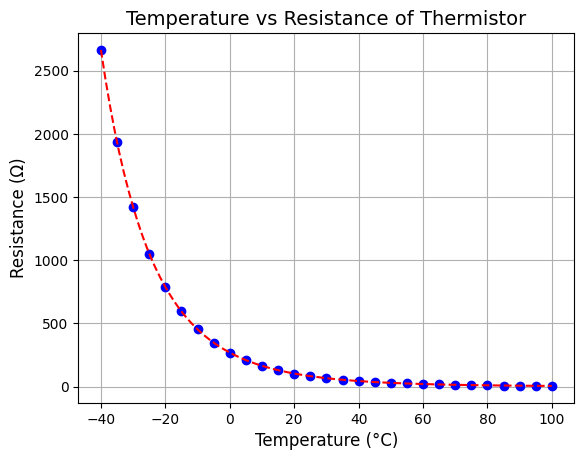

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as interpolate
temperature = np.array([
    -40, -35, -30, -25, -20, -15, -10, -5,
      0,   5,  10,  15,  20,  25,  30,  35,
     40,  45,  50,  55,  60,  65,  70,  75,
     80,  85,  90,  95, 100
])
resistance_nominal = np.array([
    2664.0, 1933.0, 1421.0, 1052.0,  788.5,  594.4,  453.0,  347.6,
     269.3,  209.7,  164.8,  130.1,  103.6,   83.00,  66.91,  54.19,
      44.18,  36.17,  29.80,  24.65,  20.51,  17.13,  14.37,  12.10,
      10.24,   8.700,  7.419,  6.351,  5.460
]) #kOhm
fit = interpolate.interp1d(temperature, resistance_nominal, kind='cubic')
temperature_fit = np.linspace(temperature.min(), temperature.max(), 100)
resistance_fit = fit(temperature_fit)
fig, ax = plt.subplots()
ax.plot(temperature, resistance_nominal, marker='o', color = 'blue',linestyle='None', label='Data Points')
ax.plot(temperature_fit, resistance_fit, label='Fit', linestyle='--', color='red')
ax.set_xlabel('Temperature (°C)',   fontsize=12)
ax.set_ylabel('Resistance (Ω)', fontsize=12)
ax.set_title('Temperature vs Resistance of Thermistor', fontsize=14)
ax.grid()
# plt.savefig('C:\\Users\\eskil\\OneDrive\\DTU\\6.sem\\bachelor_project\\figures\\thermistor_fit.pdf', dpi=300)


In [ ]:
print(f"Fitted")

Fitted


In [ ]:
def resistance_from_temperature(temp):
    """
    Calculate the resistance of the NTC thermistor for a given temperature using cubic spline interpolation.
    """
    return fit(temp)
def temperature_from_resistance(res):
    """
    Calculate the temperature corresponding to a given resistance using the cubic spline fit.
    """
    # Create an inverse function for the fit
    inverse_fit = interpolate.interp1d(resistance_fit, temperature_fit, kind='cubic', fill_value="extrapolate")
    return inverse_fit(res)
resistance = 54
temperature_calculated = temperature_from_resistance(resistance)
print(f"Calculated temperature for resistance {resistance} kΩ: {temperature_calculated:.2f} °C")


Calculated temperature for resistance 54 kΩ: 35.08 °C
